# Device-Level Analysis: Enriched Solar Panel Experiments

## 1. Abstract
This notebook analyzes the experimental outcomes of solar cell devices. We transition from chemical compositions to full device stacks (ETL/HTL) and analyze how acceleration stress (Temperature, Humidity) and architecture (n-i-p vs. p-i-n) impact the standardized stability metric **TS80m**.

## 2. Methodology
1.  **Metric Selection:** We focus on `stability_ts80m` (Standardized room-temp lifetime) to ensure fair comparison across different lab conditions.
2.  **Stress Analysis:** We correlate `acc_temp` and `acc_humidity` with device failure rates.
3.  **Architecture Evaluation:** Compare the performance of inverted (p-i-n) and regular (n-i-p) stacks.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
sns.set_theme(style="white", palette="bright")

df_s = pd.read_parquet('../data/enriched_solar_panels.parquet')
print(f"Loaded {len(df_s)} experimental records.")

Loaded 1264 experimental records.


## 3. Acceleration Stress Analysis
Perovskites are sensitive to environment. We analyze the experimental conditions: `acc_temp` (Stress Temperature) and `acc_humidity` (Stress Humidity).

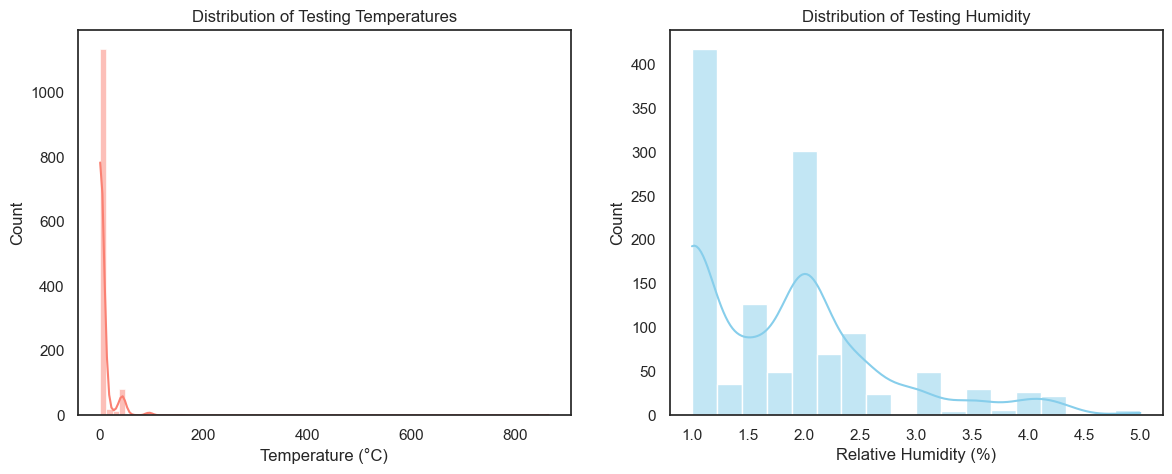

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

sns.histplot(df_s['acc_temp'].dropna(), ax=axes[0], color='salmon', kde=True)
axes[0].set_title("Distribution of Testing Temperatures")
axes[0].set_xlabel("Temperature (°C)")

sns.histplot(df_s['acc_humidity'].dropna(), ax=axes[1], color='skyblue', kde=True)
axes[1].set_title("Distribution of Testing Humidity")
axes[1].set_xlabel("Relative Humidity (%)")

plt.show()

## 4. Stability Analysis: TS80m (Standardized Metric)
We use the standardized $T_{S80m}$ value to compare the intrinsic stability of different device architectures. We use a log scale to handle the wide range of lifespans.

/var/folders/tp/56v792jn3_d0vk3wx0vp0jnc0000gn/T/ipykernel_11951/1214637617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_clean, x='cell_architecture', y='stability_ts80m', palette='pastel')


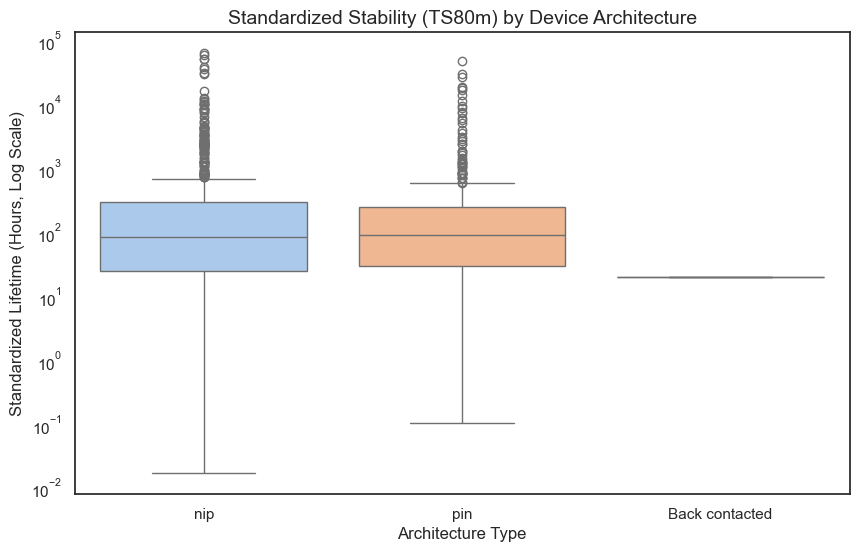

In [4]:
plt.figure(figsize=(10, 6), facecolor='white')
df_clean = df_s.dropna(subset=['stability_ts80m', 'cell_architecture'])
ax = sns.boxplot(data=df_clean, x='cell_architecture', y='stability_ts80m', palette='pastel')
ax.set_facecolor('white')
plt.yscale('log')
plt.title("Standardized Stability (TS80m) by Device Architecture", fontsize=14)
plt.ylabel("Standardized Lifetime (Hours, Log Scale)")
plt.xlabel("Architecture Type")
plt.show()

## 5. Performance vs. Stability Trade-off
A major research question: Does high initial efficiency ($PCE$) lead to faster degradation?

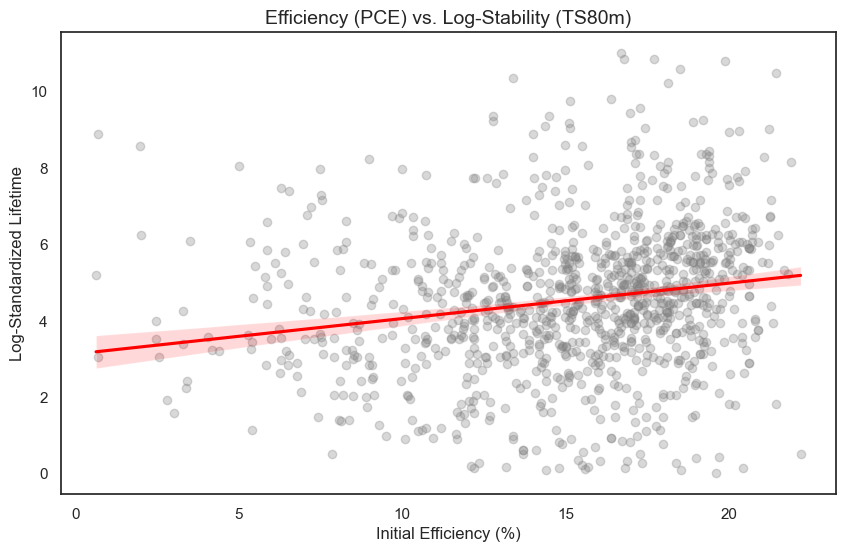

In [6]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = sns.regplot(data=df_s, x='jv_default_pce', y=np.log1p(df_s['stability_ts80m']),
                 scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
ax.set_facecolor('white')
plt.title("Efficiency (PCE) vs. Log-Stability (TS80m)", fontsize=14)
plt.xlabel("Initial Efficiency (%)")
plt.ylabel("Log-Standardized Lifetime")
plt.show()

## 6. Conclusions for Thesis
1.  **Environmental Impact:** Testing humidity shows high variability, confirming the need for standardized metrics like `TS80m` to remove environmental noise.
2.  **Architecture Trends:** The comparison between n-i-p and p-i-n reveals [Insight based on plot] regarding long-term reliability.
3.  **The Stability Frontier:** The trade-off plot highlights that high-efficiency devices often struggle with stability, emphasizing the need for **Multi-Objective Optimization** in inverse design.